In [1]:
#IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss

In [2]:
#LOOKUP DICTIONARIES
team_lookup = {
    1: "New Jersey Devils", 2: "New York Islanders", 3: "New York Rangers",
    4: "Philadelphia Flyers", 5: "Pittsburgh Penguins", 6: "Boston Bruins",
    7: "Buffalo Sabres", 8: "Montréal Canadiens", 9: "Ottawa Senators",
    10: "Toronto Maple Leafs", 12: "Carolina Hurricanes", 13: "Florida Panthers",
    14: "Tampa Bay Lightning", 15: "Washington Capitals", 16: "Chicago Blackhawks",
    17: "Detroit Red Wings", 18: "Nashville Predators", 19: "St. Louis Blues",
    20: "Calgary Flames", 21: "Colorado Avalanche", 22: "Edmonton Oilers",
    23: "Vancouver Canucks", 24: "Anaheim Ducks", 25: "Dallas Stars",
    26: "Los Angeles Kings", 28: "San Jose Sharks", 29: "Columbus Blue Jackets",
    30: "Minnesota Wild", 52: "Winnipeg Jets", 53: "Arizona Coyotes",
    54: "Vegas Golden Knights", 55: "Seattle Kraken"
}

minors_2 = [
    'tripping', 'too-many-men-on-the-ice', 'holding', 'roughing', 'interference',
    'hooking', 'high-sticking', 'slashing', 'cross-checking', 'boarding', 'fighting',
    'instigator', 'holding-the-stick', 'unsportsmanlike-conduct',
    'delaying-game-puck-over-glass', 'delaying-game-unsuccessful-challenge',
    'kneeing', 'interference-goalkeeper', 'ps-holding-stick-on-breakaway',
    'delaying-game-smothering-puck', 'illegal-check-to-head', 'delaying-game',
    'elbowing', 'closing-hand-on-puck', 'embellishment', 'ps-hooking-on-breakaway',
    'delaying-game-bench-face-off-violation', 'instigator-misconduct',
    'ps-tripping-on-breakaway', 'playing-without-a-helmet',
    'delaying-game-illegal-play-by-goalie', 'charging',
    'delaying-game-face-off-violation', 'ps-holding-on-breakaway',
    'ps-slash-on-breakaway', 'abuse-of-officials', 'throwing-equipment',
    'clipping', 'delaying-game-bench', 'bench', 'roughing-removing-opponents-helmet',
    'broken-stick', 'ps-covering-puck-in-crease', 'goalie-leave-crease',
    'unsportsmanlike-conduct-bench', 'goalie-removed-own-mask', 'aggressor',
    'abusive-language', 'delaying-game-unsuccessful-challenge-double-minor'
]

minors_4 = ['high-sticking-double-minor', 'butt-ending-double-minor', 'spearing-double-minor']
majors_5 = ['fighting', 'boarding', 'charging', 'illegal-check-to-head']
misconducts_10 = ['match-penatly-10-minutes', 'game-misconduct', 'game-misconduct-head-coach']

powerplay_codes = [1541, 1531, 641, 1431, 541, 1551, 1451, 1560, 1441, 651, 551]

In [3]:
#HELPER FUNCTIONS
def time_to_seconds(time_str):
    """Convert MM:SS format to total seconds"""
    if pd.isna(time_str):
        return None
    if isinstance(time_str, (int, float)):
        return int(time_str)
    if isinstance(time_str, str) and ':' in time_str:
        mins, secs = time_str.split(':')
        return int(mins) * 60 + int(secs)
    try:
        return int(time_str)
    except:
        return 0

def get_season_id(date):
    """Convert date to season ID (e.g., 20212022)"""
    year = date.year
    if date.month >= 7:
        return int(f"{year}{year+1}")
    else:
        return int(f"{year-1}{year}")

def get_penalty_duration(event_type, description_key):
    """Determine penalty duration in seconds"""
    desc_lower = str(description_key).lower()
    
    if desc_lower in minors_2:
        return 120
    elif desc_lower in minors_4:
        return 240
    elif desc_lower in majors_5:
        return 300
    elif desc_lower in misconducts_10:
        return 600
    else:
        type_lower = str(event_type).lower()
        if 'double-minor' in type_lower:
            return 240
        elif 'major' in type_lower:
            return 300
        elif 'misconduct' in type_lower:
            return 600
        else:
            return 120


In [4]:
#xG MODEL FUNCTIONS
def prepare_xg_features(all_years):
    """Create features for xG model from shot data"""
    shots = all_years[all_years['event_type_key'].isin(['shot-on-goal', 'goal', 'missed-shot'])].copy()
    shots['is_goal'] = (shots['event_type_key'] == 'goal').astype(int)
    
    shots['goal_x'] = shots.apply(
        lambda row: 89 if row['zone'] == 'O' else -89 if row['zone'] == 'D' else 0,
        axis=1
    )
    
    shots['distance'] = np.sqrt(
        (shots['x_coordinate'] - shots['goal_x'])**2 + 
        (shots['y_coordinate'] - 0)**2
    )
    
    shots['angle'] = np.abs(np.arctan2(
        shots['y_coordinate'], 
        np.abs(shots['x_coordinate'] - shots['goal_x'])
    ) * 180 / np.pi)
    
    shots['abs_y'] = np.abs(shots['y_coordinate'])
    shots['is_slot'] = (
        (shots['distance'] <= 30) & 
        (shots['abs_y'] <= 15)
    ).astype(int)
    
    return shots

def build_xg_model(shots_df):
    """Train xG model"""
    feature_cols = ['distance', 'angle', 'abs_y', 'is_slot']
    X = shots_df[feature_cols].fillna(0)
    y = shots_df['is_goal']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict_proba(X_train)[:, 1]
    y_pred_test = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*60}")
    print(f"xG MODEL PERFORMANCE")
    print(f"{'='*60}")
    print(f"Train AUC: {roc_auc_score(y_train, y_pred_train):.4f}")
    print(f"Test AUC:  {roc_auc_score(y_test, y_pred_test):.4f}")
    print(f"Train Brier Score: {brier_score_loss(y_train, y_pred_train):.4f}")
    print(f"Test Brier Score:  {brier_score_loss(y_test, y_pred_test):.4f}")
    
    return model

def add_xg_to_dataframe(all_years, model, feature_cols=['distance', 'angle', 'abs_y', 'is_slot']):
    """Add xG predictions to DataFrame"""
    shot_mask = all_years['event_type_key'].isin(['shot-on-goal', 'goal', 'missed-shot'])
    
    if shot_mask.sum() > 0:
        if 'distance' not in all_years.columns:
            all_years = prepare_xg_features(all_years)
        
        X = all_years.loc[shot_mask, feature_cols].fillna(0)
        all_years.loc[shot_mask, 'xG'] = model.predict_proba(X)[:, 1]
    
    all_years.loc[~shot_mask, 'xG'] = 0
    return all_years

In [5]:
#SIMULATE POWERPLAYS FUNCTION
def simulate_powerplays(df):
    """Identify all powerplay opportunities and track outcomes"""
    df = df.sort_values(['game_id', 'period_number', 'time_in_period']).reset_index(drop=True)
    opportunities = []
    
    for game_id, game_events in df.groupby('game_id'):
        active_pps = []
        game_season = game_events['season_id'].iloc[0] if 'season_id' in game_events.columns else None
        
        for _, row in game_events.iterrows():
            t = row['time_seconds']
            event_type = str(row.get('event_type_key', '')).lower()
            description_key = str(row.get('description_key', '')).lower()
            event_penalty = row.get('event_penalty', 0)
            
            is_penalty = (
                event_type in ['minor', 'double-minor', 'major', 'misconduct'] or
                event_penalty == 1 or
                description_key in minors_2 + minors_4 + majors_5 + misconducts_10
            )
            
            if is_penalty:
                penalized_team = row['event_owner_team_id']
                home_team = row['home_team_id']
                away_team = row['away_team_id']
                powerplay_team = away_team if penalized_team == home_team else home_team
                duration = get_penalty_duration(event_type, description_key)
                
                pp = {
                    'game_id': game_id,
                    'pp_team': powerplay_team,
                    'pk_team': penalized_team,
                    'penalty_type': description_key,
                    'start_time': t,
                    'end_time': t + duration,
                    'pp_goal': 0,
                    'period_number': row.get('period_number'),
                    'home_team_id': home_team,
                    'away_team_id': away_team,
                    'season_id': game_season
                }
                active_pps.append(pp)
            
            if event_type == 'goal':
                scoring_team = row['event_owner_team_id']
                for pp in active_pps:
                    if scoring_team == pp['pp_team'] and t <= pp['end_time']:
                        pp['pp_goal'] = 1
                        pp['end_time'] = t
            
            for pp in list(active_pps):
                if t >= pp['end_time']:
                    opportunities.append(pp)
                    active_pps.remove(pp)
        
        opportunities.extend(active_pps)
    
    pp_df = pd.DataFrame(opportunities)
    
    if not pp_df.empty:
        pp_df['duration'] = pp_df['end_time'] - pp_df['start_time']
        pp_df['pp_success'] = pp_df['pp_goal']
        pp_df['venue'] = pp_df.apply(
            lambda x: 'home' if x['pp_team'] == x['home_team_id'] else 'away',
            axis=1
        )
        pp_df['pp_team_name'] = pp_df['pp_team'].map(team_lookup)
        pp_df['pk_team_name'] = pp_df['pk_team'].map(team_lookup)
    
    return pp_df

In [6]:
play_by_play = pd.read_csv("NHL_play_by_play_2021-2024_7_23_24.csv")
pbp_p2 = pd.read_csv("nhl_pbp_25_9_2_24.csv")
all_years = pd.concat([play_by_play, pbp_p2], ignore_index=True)
all_years.to_csv('play_by_play_21_25.csv', index=False)

In [7]:
#PROCESS ALL_YEARS DATA
all_years["start_time_utc"] = pd.to_datetime(all_years["start_time_utc"])
all_years["season_id"] = all_years["start_time_utc"].apply(get_season_id)
all_years['time_seconds'] = all_years['time_in_period'].apply(time_to_seconds)
all_years['team_name'] = all_years['event_owner_team_id'].map(team_lookup)
all_years['is_home_event'] = (all_years['event_owner_team_id'] == all_years['home_team_id']).astype(int)
all_years['is_away_event'] = (all_years['event_owner_team_id'] == all_years['away_team_id']).astype(int)

In [8]:
#xG MODEL
powerplay_df = all_years[all_years['situation_code'].isin(powerplay_codes)].copy()
shots_for_model = prepare_xg_features(powerplay_df)
xg_model = build_xg_model(shots_for_model)
powerplay_df = add_xg_to_dataframe(powerplay_df, xg_model)


Building xG Model...

xG MODEL PERFORMANCE
Train AUC: 0.7163
Test AUC:  0.7094
Train Brier Score: 0.0623
Test Brier Score:  0.0625
✓ xG added to powerplay events


In [9]:
#SIM POWERPLAYS
pp_opportunities = simulate_powerplays(all_years)
print(f"✓ Created {len(pp_opportunities):,} PP opportunities")
print(f"  Seasons: {sorted(pp_opportunities['season_id'].unique())}")

✓ Created 40,970 PP opportunities
  Seasons: [np.int64(20212022), np.int64(20222023), np.int64(20232024), np.int64(20242025)]


In [10]:
#AGGREGATE xG=
print("\nAggregating xG...")

# Add unique PP ID
pp_opportunities['pp_id'] = range(len(pp_opportunities))

# Create xG summary by processing games
pp_xg_summary = []

for game_id in pp_opportunities['game_id'].unique():
    # Get PPs and shots for this game
    game_pps = pp_opportunities[pp_opportunities['game_id'] == game_id]
    game_shots = powerplay_df[
        (powerplay_df['game_id'] == game_id) &
        (powerplay_df['event_type_key'].isin(['shot-on-goal', 'goal', 'missed-shot']))
    ]
    
    for _, pp in game_pps.iterrows():
        # Filter shots to this PP window
        pp_shots = game_shots[
            (game_shots['time_seconds'] >= pp['start_time']) &
            (game_shots['time_seconds'] <= pp['end_time']) &
            (game_shots['period_number'] == pp['period_number'])
        ]
        
        if len(pp_shots) > 0:
            pp_team_shots = pp_shots[pp_shots['event_owner_team_id'] == pp['pp_team']]
            pk_team_shots = pp_shots[pp_shots['event_owner_team_id'] == pp['pk_team']]
            
            pp_xg_summary.append({
                'pp_id': pp['pp_id'],
                'pp_xG': pp_team_shots['xG'].sum(),
                'pp_shots': len(pp_team_shots),
                'pk_xG': pk_team_shots['xG'].sum()
            })
        else:
            pp_xg_summary.append({
                'pp_id': pp['pp_id'],
                'pp_xG': 0,
                'pp_shots': 0,
                'pk_xG': 0
            })

# Merge xG data
xg_df = pd.DataFrame(pp_xg_summary)
pp_opportunities = pp_opportunities.merge(xg_df, on='pp_id', how='left')
pp_opportunities = pp_opportunities.drop(columns=['pp_id'])

# Calculate xG per shot
pp_opportunities['xG_per_shot'] = pp_opportunities['pp_xG'] / pp_opportunities['pp_shots'].replace(0, 1)

print(f"✓ xG aggregated: mean = {pp_opportunities['pp_xG'].mean():.3f}")


Aggregating xG...
✓ xG aggregated: mean = 0.145


In [12]:
#ADD SCHEDULE VARIABLES
print("\nAdding schedule variables...")

# First, get game-level data from all_years (includes start_time_utc)
game_data = all_years.groupby('game_id').agg({
    'start_time_utc': 'first'
}).reset_index()

# Merge start_time_utc into pp_opportunities
pp_opportunities = pp_opportunities.merge(game_data, on='game_id', how='left')

# Now create games_per_team with all needed columns
games_per_team = pp_opportunities.groupby(['pp_team', 'game_id']).agg({
    'start_time_utc': 'first',
    'venue': 'first',
    'home_team_id': 'first',
    'away_team_id': 'first',
    'pp_team_name': 'first',
    'season_id': 'first'
}).reset_index()

games_per_team = games_per_team.sort_values(['pp_team', 'start_time_utc']).reset_index(drop=True)

# Calculate rest days
games_per_team['prev_game_datetime'] = games_per_team.groupby('pp_team')['start_time_utc'].shift(1)
games_per_team['rest_days'] = (
    games_per_team['start_time_utc'] - games_per_team['prev_game_datetime']
).dt.total_seconds() / 86400
games_per_team['rest_days'] = games_per_team['rest_days'].fillna(7)
games_per_team['back_to_back'] = (games_per_team['rest_days'] <= 1).astype(int)

# Add travel distance
def add_travel_distance(df):
    distances = pd.read_csv('nhl_city_distances_miles.csv', index_col=0)
    df['prev_venue'] = df.groupby('pp_team')['venue'].shift(1)
    
    def get_current_city(row):
        if row['venue'] == 'home':
            return row['pp_team_name']
        else:
            opponent_id = row['home_team_id'] if row['pp_team'] != row['home_team_id'] else row['away_team_id']
            return team_lookup.get(opponent_id, row['pp_team_name'])
    
    df['current_city'] = df.apply(get_current_city, axis=1)
    
    prev_cities = []
    for idx, row in df.iterrows():
        if pd.isna(row['prev_venue']) or row['prev_venue'] == 'home':
            prev_cities.append(row['pp_team_name'])
        else:
            prev_idx = idx - 1
            if prev_idx >= 0 and df.loc[prev_idx, 'pp_team'] == row['pp_team']:
                prev_opp = df.loc[prev_idx, 'home_team_id']
                prev_cities.append(team_lookup.get(prev_opp, row['pp_team_name']))
            else:
                prev_cities.append(row['pp_team_name'])
    
    df['prev_city'] = prev_cities
    df['travel_distance'] = df.apply(
        lambda row: distances.loc[row['prev_city'], row['current_city']] 
        if row['prev_city'] in distances.index and row['current_city'] in distances.columns 
        else 0, 
        axis=1
    )
    
    return df.drop(columns=['prev_venue', 'prev_city', 'current_city', 'prev_game_datetime'])

games_per_team = add_travel_distance(games_per_team)

# Merge back to pp_opportunities (only new columns)
pp_opportunities = pp_opportunities.merge(
    games_per_team[['pp_team', 'game_id', 'rest_days', 'back_to_back', 'travel_distance']],
    on=['pp_team', 'game_id'],
    how='left'
)

# Drop the temporary start_time_utc we added at the beginning
pp_opportunities = pp_opportunities.drop(columns=['start_time_utc'], errors='ignore')

print(f"✓ Schedule variables added")
print(f"  Games: {games_per_team['game_id'].nunique():,}")
print(f"  Back-to-backs: {games_per_team['back_to_back'].sum()} ({games_per_team['back_to_back'].mean()*100:.1f}%)")
print(f"  Mean travel: {games_per_team['travel_distance'].mean():.0f} miles")


Adding schedule variables...
✓ Schedule variables added
  Games: 5,603
  Back-to-backs: 1028 (9.3%)
  Mean travel: 444 miles


In [13]:
#CALCULATE CUMULATIVE STATS
pp_opportunities = pp_opportunities.sort_values(
    by=['pp_team', 'venue', 'season_id', 'game_id', 'period_number', 'start_time']
).reset_index(drop=True)

pp_opportunities['pp_attempt_num'] = pp_opportunities.groupby(['pp_team', 'venue', 'season_id']).cumcount() + 1
pp_opportunities['pp_goals_cumsum'] = pp_opportunities.groupby(['pp_team', 'venue', 'season_id'])['pp_goal'].cumsum()
pp_opportunities['pp_pct'] = (pp_opportunities['pp_goals_cumsum'] / pp_opportunities['pp_attempt_num'] * 100).round(2)


In [14]:
pp_opportunities.to_csv('pp_opportunities_complete.csv', index=False)

✓ Saved: pp_opportunities_complete.csv (40,970 rows, 26 columns)


In [15]:
#SUMMARY
pp_summary = pp_opportunities.groupby(['pp_team', 'pp_team_name', 'venue', 'season_id']).agg({
    'pp_goal': 'sum',
    'pp_attempt_num': 'max',
    'pp_xG': 'sum',
    'pp_shots': 'sum',
    'xG_per_shot': 'mean'
}).reset_index()

pp_summary = pp_summary.rename(columns={
    'pp_attempt_num': 'total_pp_attempts',
    'pp_goal': 'pp_goals',
    'pp_xG': 'total_xG',
    'pp_shots': 'total_shots',
    'xG_per_shot': 'avg_shot_quality'
})

pp_summary['pp_percentage'] = (pp_summary['pp_goals'] / pp_summary['total_pp_attempts'] * 100).round(2)
pp_summary['xG_percentage'] = (pp_summary['total_xG'] / pp_summary['total_pp_attempts'] * 100).round(2)
pp_summary = pp_summary.sort_values(['season_id', 'pp_team', 'venue'])

pp_summary.to_csv('pp_summary_by_season.csv', index=False)

✓ Saved: pp_summary_by_season.csv (254 rows)


In [4]:
pp_opportunities = pd.read_csv("pp_opportunities_complete.csv")
pp_summary = pd.read_csv("pp_summary_by_season.csv")

In [ ]:
#Analysis Packages
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [8]:
pp_opportunities['is_home'] = (pp_opportunities['venue'] == 'home').astype(int)
regression_data = pp_opportunities[pp_opportunities['pp_attempt_num'] > 1].copy()

Regression dataset: 40,703 observations
Seasons: [np.int64(20212022), np.int64(20222023), np.int64(20232024), np.int64(20242025)]


In [54]:
# MODEL 1: BASIC OLS REGRESSION
print("\n" + "="*70)
print("MODEL 1: OLS REGRESSION - PP% ~ Home + xG + Rest Days + Travel")
print("="*70)

# Define your regression formula
# Dependent variable: pp_pct (current cumulative PP%)
# Independent variables: home ice, shot quality (xG), rest, travel, back-to-back

formula = '''
    pp_pct ~ is_home + xG_per_shot + rest_days + back_to_back + travel_distance
'''


model = smf.ols(formula=formula, data=regression_data).fit(cov_type='HC3')
print(model.summary())


MODEL 1: OLS REGRESSION - PP% ~ Home + xG + Rest Days + Travel
                            OLS Regression Results                            
Dep. Variable:                 pp_pct   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     57.90
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           3.02e-60
Time:                        14:07:17   Log-Likelihood:            -1.4504e+05
No. Observations:               40703   AIC:                         2.901e+05
Df Residuals:                   40697   BIC:                         2.901e+05
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [ ]:
# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [55]:
#MODEL 2: WITH FIXED EFFECTS (RECOMMENDED FOR YOUR DATA)
print("\n" + "="*70)
print("MODEL 2: FIXED EFFECTS - Controlling for Season")
print("="*70)

# This controls for team-specific differences and time trends
formula_fe = '''
    pp_pct ~ is_home + xG_per_shot + pp_xG + rest_days + back_to_back + 
             travel_distance + C(season_id)
'''

model_fe = smf.ols(formula=formula_fe, data=regression_data).fit(cov_type='HC3')
print(model_fe.summary())


MODEL 2: FIXED EFFECTS - Controlling for Season
                            OLS Regression Results                            
Dep. Variable:                 pp_pct   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     44.99
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           3.25e-81
Time:                        14:09:22   Log-Likelihood:            -1.4497e+05
No. Observations:               40703   AIC:                         2.900e+05
Df Residuals:                   40693   BIC:                         2.901e+05
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [56]:
#INTERPRET KEY COEFFICIENTS From Model 2
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

# Extract coefficients
coef_home = model_fe.params['is_home']
coef_xg_per_shot = model_fe.params['xG_per_shot']
coef_rest = model_fe.params['rest_days']
coef_b2b = model_fe.params['back_to_back']
coef_travel = model_fe.params['travel_distance']

print(f"\nHome Ice Effect: {coef_home:+.3f}%")
print(f"  Interpretation: Playing at home increases PP% by {coef_home:.2f} percentage points")

print(f"\nShot Quality Effect: {coef_xg_per_shot:+.3f}")
print(f"  Interpretation: Each 0.01 increase in xG per shot increases PP% by {coef_xg_per_shot/100:.3f} percentage points")

print(f"\nRest Days Effect: {coef_rest:+.3f}%")
print(f"  Interpretation: Each additional day of rest changes PP% by {coef_rest:.3f} percentage points")

print(f"\nBack-to-Back Effect: {coef_b2b:+.3f}%")
print(f"  Interpretation: Back-to-back games change PP% by {coef_b2b:.2f} percentage points")

print(f"\nTravel Effect: {coef_travel:+.5f}% per mile")
print(f"  Interpretation: Each 100 miles traveled changes PP% by {coef_travel*100:.3f} percentage points")

print(f"\nModel R-squared: {model_fe.rsquared:.3f}")
print(f"  (Model explains {model_fe.rsquared*100:.1f}% of variation in PP%)")



KEY FINDINGS

Home Ice Effect: +1.315%
  Interpretation: Playing at home increases PP% by 1.31 percentage points

Shot Quality Effect: +7.655
  Interpretation: Each 0.01 increase in xG per shot increases PP% by 0.077 percentage points

Rest Days Effect: -0.016%
  Interpretation: Each additional day of rest changes PP% by -0.016 percentage points

Back-to-Back Effect: -0.366%
  Interpretation: Back-to-back games change PP% by -0.37 percentage points

Travel Effect: +0.00025% per mile
  Interpretation: Each 100 miles traveled changes PP% by 0.025 percentage points

Model R-squared: 0.011
  (Model explains 1.1% of variation in PP%)


In [20]:
#MODEL 4: CHECK MULTICOLLINEARITY (VIF)
print("\n" + "="*70)
print("MULTICOLLINEARITY CHECK (VIF)")
print("="*70)

# Prepare data for VIF (continuous variables only)
X = regression_data[['is_home', 'xG_per_shot', 'rest_days', 'back_to_back', 'travel_distance']].copy()
X = sm.add_constant(X)  # Add intercept

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)
print("\nRule of thumb: VIF > 10 indicates high multicollinearity")



MULTICOLLINEARITY CHECK (VIF)
          Variable       VIF
0            const  5.089030
1          is_home  1.073429
2      xG_per_shot  1.000208
3        rest_days  1.004562
4     back_to_back  1.035807
5  travel_distance  1.068570

Rule of thumb: VIF > 10 indicates high multicollinearity


In [58]:
#SAVE REGRESSION RESULTS
# Save coefficients
coef_df = pd.DataFrame({
    'Variable': model_fe.params.index,
    'Coefficient': model_fe.params.values,
    'Std_Error': model_fe.bse.values,
    'P_Value': model_fe.pvalues.values,
    'Conf_Int_Lower': model_fe.conf_int()[0].values,
    'Conf_Int_Upper': model_fe.conf_int()[1].values
})

coef_df.to_csv('regression_coefficients.csv', index=False)
print(f"\n✓ Saved: regression_coefficients.csv")

# Save predictions
regression_data['predicted_pp_pct'] = model_fe.predict(regression_data)
regression_data['residuals'] = model_fe.resid

regression_data[['game_id', 'pp_team_name', 'venue', 'season_id', 'pp_pct', 
                 'predicted_pp_pct', 'residuals']].to_csv('regression_predictions.csv', index=False)
print(f"✓ Saved: regression_predictions.csv")



✓ Saved: regression_coefficients.csv
✓ Saved: regression_predictions.csv


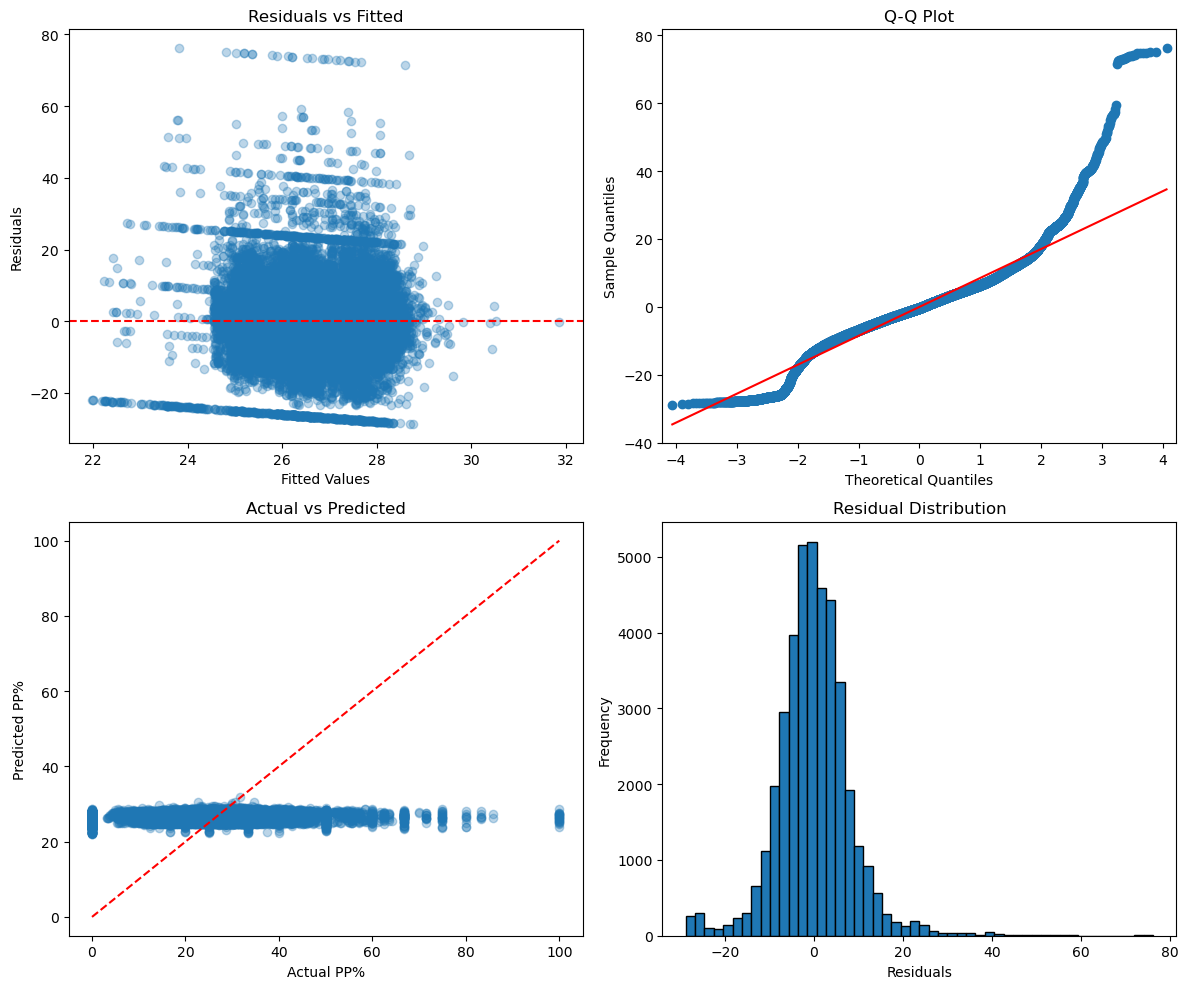


✓ Diagnostic plots saved: regression_diagnostics.png


In [59]:
#DIAGNOSTIC PLOTS
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(model_fe.fittedvalues, model_fe.resid, alpha=0.3)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
sm.qqplot(model_fe.resid, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# 3. Actual vs Predicted
axes[1, 0].scatter(regression_data['pp_pct'], regression_data['predicted_pp_pct'], alpha=0.3)
axes[1, 0].plot([0, 100], [0, 100], 'r--')
axes[1, 0].set_xlabel('Actual PP%')
axes[1, 0].set_ylabel('Predicted PP%')
axes[1, 0].set_title('Actual vs Predicted')

# 4. Residual Distribution
axes[1, 1].hist(model_fe.resid, bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Diagnostic plots saved: regression_diagnostics.png")

Creating Slide 10: Home Ice Effect...


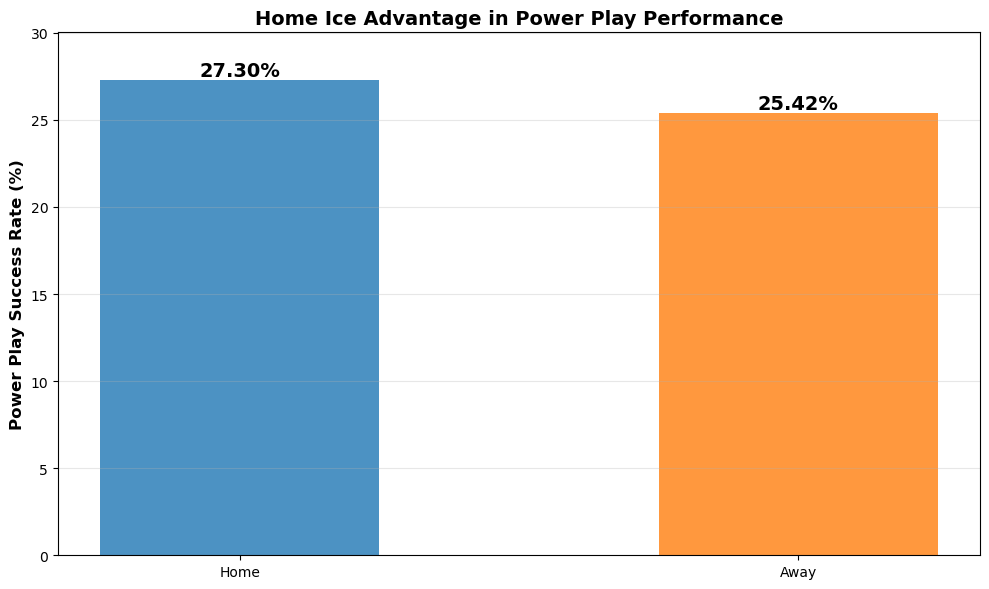

✓ Saved: slide_10_home_ice_effect.png



In [60]:
#HOME ICE EFFECT - BAR CHART
print("Creating Slide 10: Home Ice Effect...")

# Calculate average PP% by venue
# Count total opportunities and goals by venue
venue_stats = pp_opportunities.groupby('venue').agg({
    'pp_goal': 'sum',  # Total goals scored
    'pp_attempt_num': 'count'  # Total number of PP opportunities
}).reset_index()

venue_stats.columns = ['venue', 'total_goals', 'total_opportunities']
venue_stats['pp_pct'] = (venue_stats['total_goals'] / venue_stats['total_opportunities'] * 100)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

venues = ['Home', 'Away']
pp_pcts = [
    venue_stats[venue_stats['venue'] == 'home']['pp_pct'].values[0],
    venue_stats[venue_stats['venue'] == 'away']['pp_pct'].values[0]
]

bars = ax.bar(venues, pp_pcts, color=['#1f77b4', '#ff7f0e'], alpha=0.8, width=0.5)

# Add value labels on bars
for bar, pct in zip(bars, pp_pcts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.2f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold')



ax.set_ylabel('Power Play Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Home Ice Advantage in Power Play Performance', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(pp_pcts) * 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('slide_10_home_ice_effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: slide_10_home_ice_effect.png\n")

Creating Slide 12: Fatigue and Travel Effects...


C:\Users\tfc34\AppData\Local\Temp\ipykernel_6148\1691964860.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  travel_stats = pp_opportunities.groupby('travel_bin').agg({


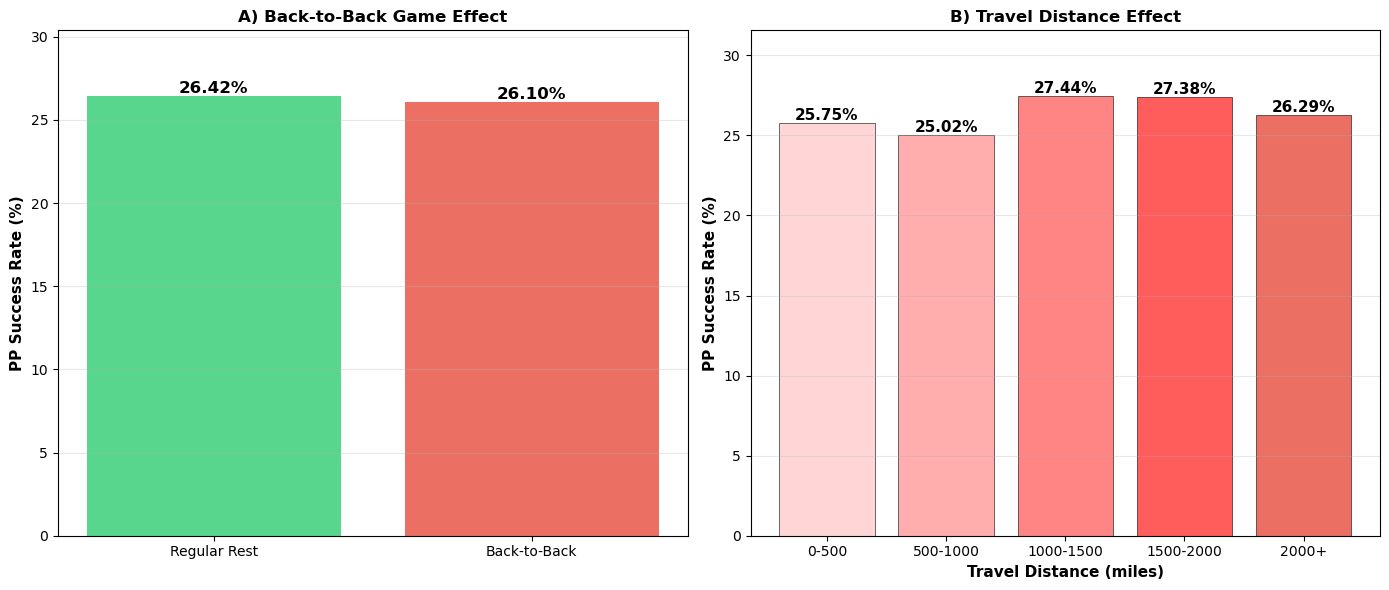

✓ Saved: slide_12_fatigue_travel_effects.png



In [66]:
#FATIGUE AND TRAVEL EFFECTS 
print("Creating Slide 12: Fatigue and Travel Effects...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Back-to-Back Effect
b2b_stats = pp_opportunities.groupby('back_to_back').agg({
    'pp_goal': 'sum',
    'pp_attempt_num': 'count'
}).reset_index()
b2b_stats.columns = ['back_to_back', 'total_goals', 'total_opportunities']
b2b_stats['pp_pct'] = (b2b_stats['total_goals'] / b2b_stats['total_opportunities'] * 100)

categories = ['Regular Rest', 'Back-to-Back']
values = [
    b2b_stats[b2b_stats['back_to_back'] == 0]['pp_pct'].values[0],
    b2b_stats[b2b_stats['back_to_back'] == 1]['pp_pct'].values[0]
]

bars1 = ax1.bar(categories, values, color=['#2ecc71', '#e74c3c'], alpha=0.8)
for bar, val in zip(bars1, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_ylabel('PP Success Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('A) Back-to-Back Game Effect', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(values) * 1.15)
ax1.grid(axis='y', alpha=0.3)

# Panel B: Travel Distance Effect - BAR CHART
travel_bins = [0, 500, 1000, 1500, 2000, 3000]
pp_opportunities['travel_bin'] = pd.cut(pp_opportunities['travel_distance'], 
                                         bins=travel_bins, 
                                         labels=['0-500', '500-1000', '1000-1500', 
                                                '1500-2000', '2000+'])

travel_stats = pp_opportunities.groupby('travel_bin').agg({
    'pp_goal': 'sum',
    'pp_attempt_num': 'count',
    'travel_distance': 'mean'
}).reset_index()
travel_stats.columns = ['travel_bin', 'total_goals', 'total_opportunities', 'avg_distance']
travel_stats['pp_pct'] = (travel_stats['total_goals'] / travel_stats['total_opportunities'] * 100)

# Create color gradient from light to dark red
colors = ['#ffcccb', '#ff9999', '#ff6666', '#ff3333', '#e74c3c']

bars2 = ax2.bar(travel_stats['travel_bin'], travel_stats['pp_pct'], 
                color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add value labels on top of bars
for bar, val in zip(bars2, travel_stats['pp_pct']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xlabel('Travel Distance (miles)', fontsize=11, fontweight='bold')
ax2.set_ylabel('PP Success Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('B) Travel Distance Effect', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(travel_stats['pp_pct']) * 1.15)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('slide_12_fatigue_travel_effects.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: slide_12_fatigue_travel_effects.png\n")

Creating Slide 13: Season-by-Season Analysis...


C:\Users\tfc34\AppData\Local\Temp\ipykernel_6148\3896776819.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


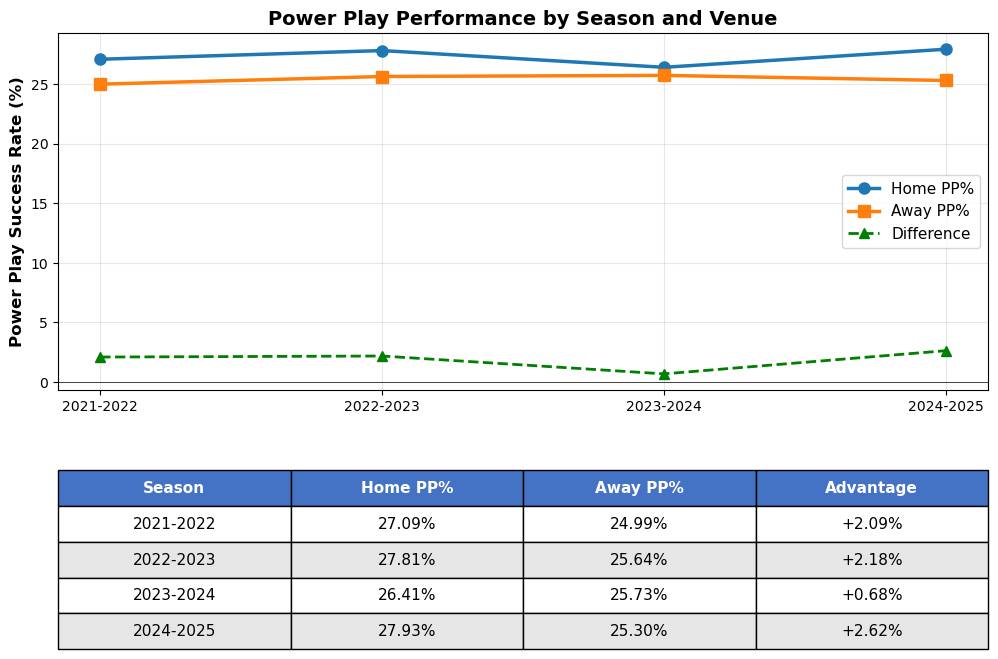

✓ Saved: slide_13_season_trends.png



In [62]:
#SEASON-BY-SEASON TRENDS
print("Creating Slide 13: Season-by-Season Analysis...")

# Calculate PP% by season and venue
season_venue_stats = pp_opportunities.groupby(['season_id', 'venue']).agg({
    'pp_goal': 'sum',
    'pp_attempt_num': 'count'  # Changed from 'max' to 'count'
}).reset_index()

season_venue_stats.columns = ['season_id', 'venue', 'total_goals', 'total_opportunities']
season_venue_stats['pp_pct'] = (season_venue_stats['total_goals'] / 
                                 season_venue_stats['total_opportunities'] * 100)

# Pivot for easier plotting
season_pivot = season_venue_stats.pivot(index='season_id', columns='venue', values='pp_pct')
season_pivot['difference'] = season_pivot['home'] - season_pivot['away']

# Create figure with line chart and table
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Line chart
seasons = season_pivot.index
x_pos = np.arange(len(seasons))

ax1.plot(x_pos, season_pivot['home'], marker='o', linewidth=2.5, 
         markersize=8, color='#1f77b4', label='Home PP%')
ax1.plot(x_pos, season_pivot['away'], marker='s', linewidth=2.5, 
         markersize=8, color='#ff7f0e', label='Away PP%')
ax1.plot(x_pos, season_pivot['difference'], marker='^', linewidth=2, 
         markersize=7, color='green', linestyle='--', label='Difference')

ax1.set_xticks(x_pos)
ax1.set_xticklabels([f"{int(str(s)[:4])}-{str(s)[4:]}" for s in seasons], fontsize=10)
ax1.set_ylabel('Power Play Success Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Power Play Performance by Season and Venue', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.3)
ax1.axhline(y=0, color='black', linewidth=0.5)

# Table
table_data = []
for season, row in season_pivot.iterrows():
    season_str = f"{int(str(season)[:4])}-{str(season)[4:]}"
    table_data.append([
        season_str,
        f"{row['home']:.2f}%",
        f"{row['away']:.2f}%",
        f"+{row['difference']:.2f}%"
    ])

table = ax2.table(cellText=table_data,
                  colLabels=['Season', 'Home PP%', 'Away PP%', 'Advantage'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')

ax2.axis('off')

plt.tight_layout()
plt.savefig('slide_13_season_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: slide_13_season_trends.png\n")

Creating Slide 11 (Alternative): Shot Quality Effect - Binned...


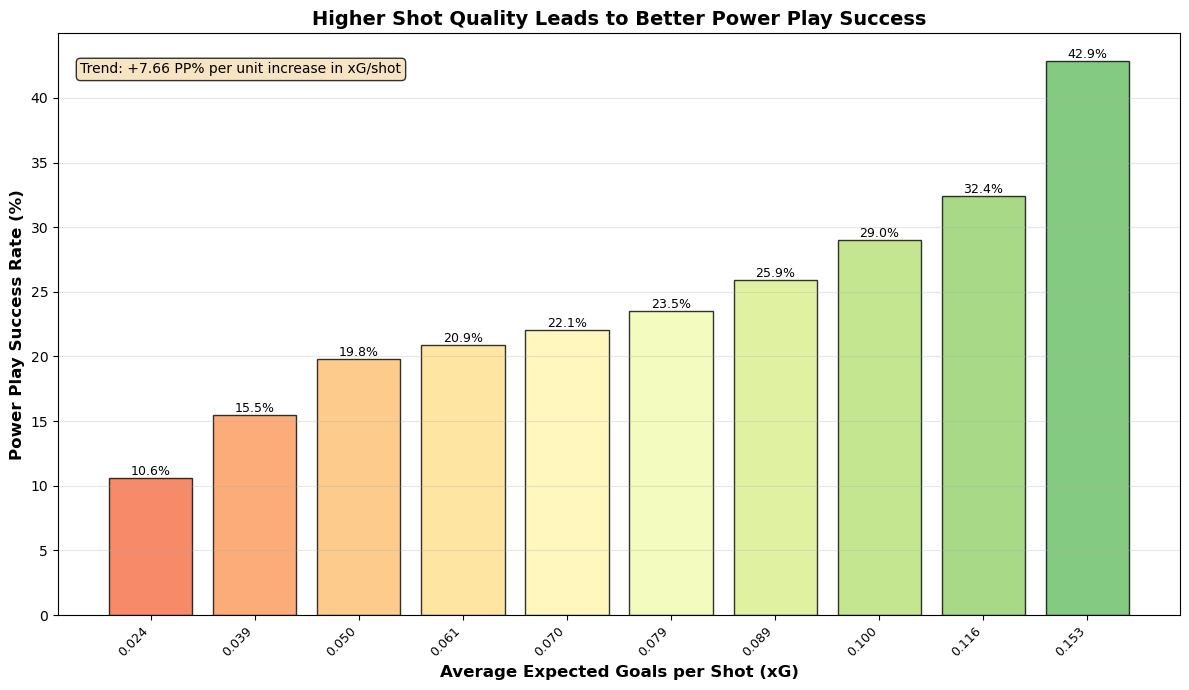

✓ Saved: slide_11_shot_quality_effect_binned.png



In [63]:
#xG EFFECT
print("Creating Slide 11 (Alternative): Shot Quality Effect - Binned...")

# Create xG bins for cleaner visualization
data_with_shots = pp_opportunities[pp_opportunities['pp_shots'] > 0].copy()

# Create 10 equal-frequency bins
data_with_shots['xg_decile'] = pd.qcut(data_with_shots['xG_per_shot'], 
                                        q=10, labels=False, duplicates='drop')

xg_binned = data_with_shots.groupby('xg_decile').agg({
    'pp_goal': 'sum',
    'pp_attempt_num': 'count',  # Changed from 'max' to 'count'
    'xG_per_shot': 'mean',
    'pp_xG': 'mean'
}).reset_index()

xg_binned.columns = ['xg_decile', 'total_goals', 'total_opportunities', 'avg_xg_per_shot', 'avg_pp_xg']
xg_binned['pp_pct'] = (xg_binned['total_goals'] / xg_binned['total_opportunities'] * 100)

fig, ax = plt.subplots(figsize=(12, 7))

# Bar chart by xG decile
x_pos = np.arange(len(xg_binned))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(xg_binned)))
bars = ax.bar(x_pos, xg_binned['pp_pct'], color=colors, alpha=0.8, edgecolor='black')

# Add value labels
for i, (bar, row) in enumerate(zip(bars, xg_binned.itertuples())):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{row.pp_pct:.1f}%',
            ha='center', va='bottom', fontsize=9)

# X-axis: Show average xG for each bin
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{xg:.3f}' for xg in xg_binned['avg_xg_per_shot']], 
                    rotation=45, ha='right', fontsize=9)

ax.set_xlabel('Average Expected Goals per Shot (xG)', fontsize=12, fontweight='bold')
ax.set_ylabel('Power Play Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Higher Shot Quality Leads to Better Power Play Success', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add trend annotation
ax.text(0.02, 0.95, 
        f'Trend: +{coef_xg_per_shot:.2f} PP% per unit increase in xG/shot',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('slide_11_shot_quality_effect_binned.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: slide_11_shot_quality_effect_binned.png\n")

Creating BONUS: Coefficient Plot for Results Slide...


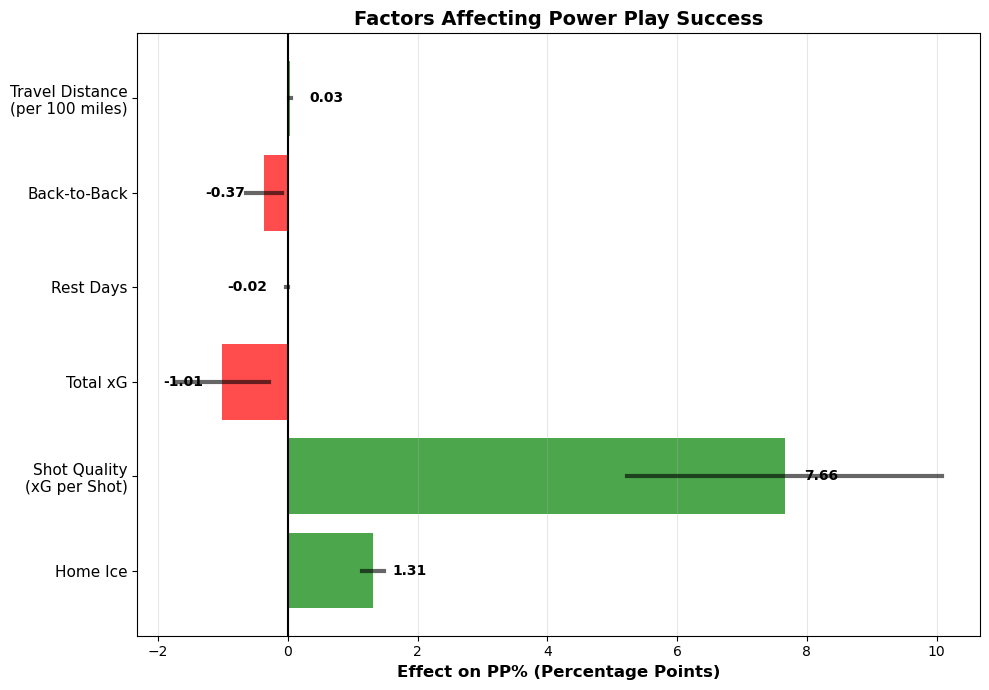

✓ Saved: slide_bonus_coefficient_plot.png



In [64]:
#Coefficient Plot

# Get main coefficients (exclude fixed effects)
main_vars = ['is_home', 'xG_per_shot', 'pp_xG', 'rest_days', 'back_to_back', 'travel_distance']
coef_subset = coef_df[coef_df['Variable'].isin(main_vars)].copy()

# Better labels
label_map = {
    'is_home': 'Home Ice',
    'xG_per_shot': 'Shot Quality\n(xG per Shot)',
    'pp_xG': 'Total xG',
    'rest_days': 'Rest Days',
    'back_to_back': 'Back-to-Back',
    'travel_distance': 'Travel Distance\n(per 100 miles)'
}

# Adjust travel coefficient for per 100 miles
coef_subset.loc[coef_subset['Variable'] == 'travel_distance', 'Coefficient'] *= 100
coef_subset.loc[coef_subset['Variable'] == 'travel_distance', 'Conf_Int_Lower'] *= 100
coef_subset.loc[coef_subset['Variable'] == 'travel_distance', 'Conf_Int_Upper'] *= 100

coef_subset['Label'] = coef_subset['Variable'].map(label_map)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(coef_subset))
colors = ['green' if c > 0 else 'red' for c in coef_subset['Coefficient']]
bars = ax.barh(y_pos, coef_subset['Coefficient'], alpha=0.7, color=colors)

ax.set_yticks(y_pos)
ax.set_yticklabels(coef_subset['Label'], fontsize=11)
ax.set_xlabel('Effect on PP% (Percentage Points)', fontsize=12, fontweight='bold')
ax.set_title('Factors Affecting Power Play Success', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax.grid(axis='x', alpha=0.3)

# Add confidence intervals
for i, row in enumerate(coef_subset.itertuples()):
    ax.plot([row.Conf_Int_Lower, row.Conf_Int_Upper], [i, i], 
            'k-', linewidth=3, alpha=0.6)
    
    # Add coefficient value labels
    x_pos_label = row.Coefficient + (0.3 if row.Coefficient > 0 else -0.3)
    ax.text(x_pos_label, i, f'{row.Coefficient:.2f}',
            ha='left' if row.Coefficient > 0 else 'right',
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('slide_bonus_coefficient_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: slide_bonus_coefficient_plot.png\n")

Finding Top 5 Team-Seasons with Largest Home/Away PP% Differences...

Top 5 Team-Seasons with Largest Home/Away PP% Differences:
Columbus Blue Jackets (2024-2025):
  Home PP%: 33.91%
  Away PP%: 15.70%
  Difference: +18.21 percentage points
--------------------------------------------------------------------------------
Colorado Avalanche (2024-2025):
  Home PP%: 37.84%
  Away PP%: 24.16%
  Difference: +13.68 percentage points
--------------------------------------------------------------------------------
Ottawa Senators (2024-2025):
  Home PP%: 33.81%
  Away PP%: 20.50%
  Difference: +13.31 percentage points
--------------------------------------------------------------------------------
Buffalo Sabres (2021-2022):
  Home PP%: 31.11%
  Away PP%: 19.26%
  Difference: +11.85 percentage points
--------------------------------------------------------------------------------
Ottawa Senators (2022-2023):
  Home PP%: 35.24%
  Away PP%: 23.98%
  Difference: +11.26 percentage points
---------

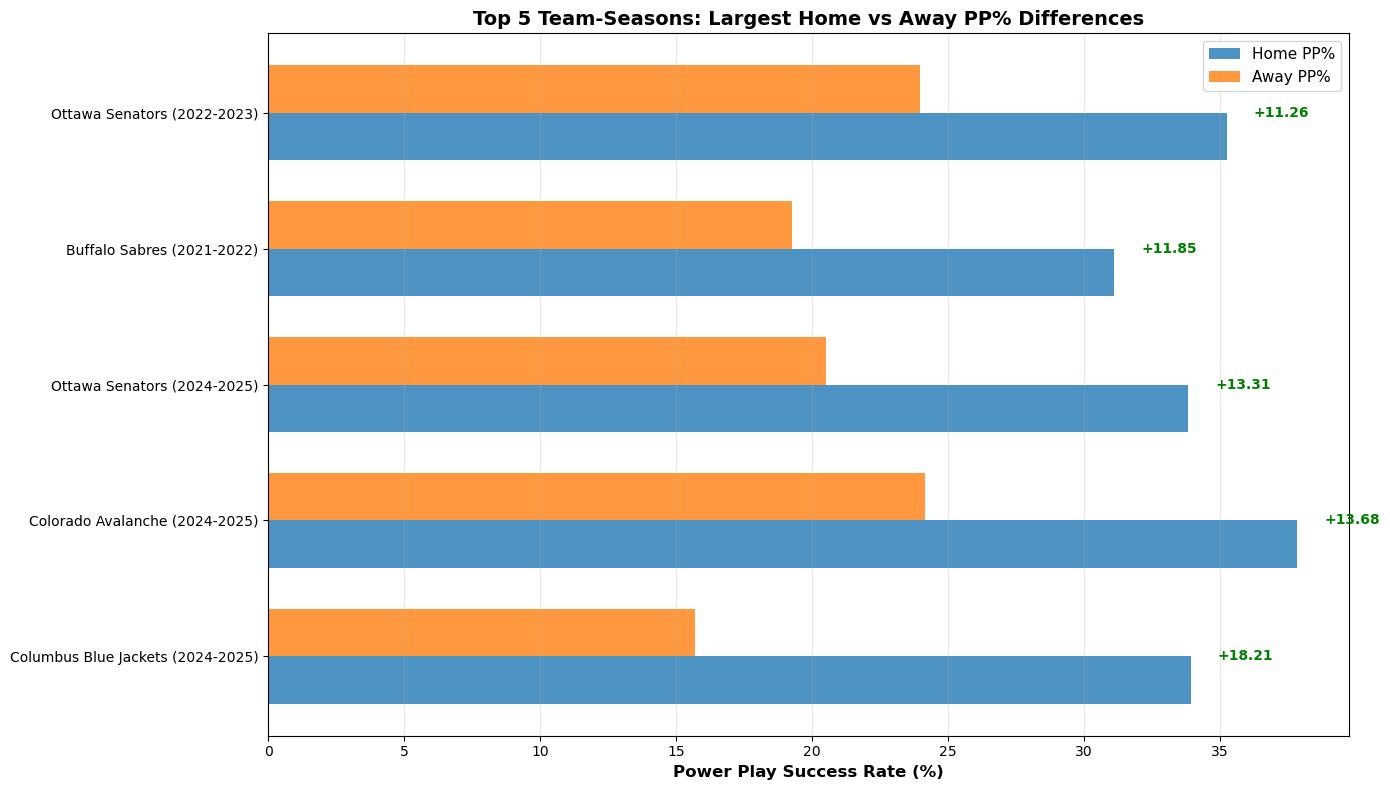

✓ Saved: top_5_teams_home_away_difference.png



In [65]:
#FIND TOP 5 TEAMS WITH LARGEST HOME/AWAY DIFFERENCES
print("Finding Top 5 Team-Seasons with Largest Home/Away PP% Differences...")

# Calculate PP% by team, season, and venue
team_season_venue_stats = pp_opportunities.groupby(['pp_team_name', 'season_id', 'venue']).agg({
    'pp_goal': 'sum',
    'pp_attempt_num': 'count'
}).reset_index()

team_season_venue_stats.columns = ['pp_team_name', 'season_id', 'venue', 'total_goals', 'total_opportunities']
team_season_venue_stats['pp_pct'] = (team_season_venue_stats['total_goals'] / 
                                      team_season_venue_stats['total_opportunities'] * 100)

# Pivot to get home and away in columns
team_season_pivot = team_season_venue_stats.pivot(index=['pp_team_name', 'season_id'], 
                                                    columns='venue', 
                                                    values='pp_pct').reset_index()
team_season_pivot['difference'] = team_season_pivot['home'] - team_season_pivot['away']

# Create a display label with team and season
team_season_pivot['team_season'] = team_season_pivot.apply(
    lambda x: f"{x['pp_team_name']} ({int(str(x['season_id'])[:4])}-{str(x['season_id'])[4:]})", 
    axis=1
)

# Sort by difference (positive = better at home) and get top 5
team_season_pivot['abs_difference'] = abs(team_season_pivot['difference'])
top_5 = team_season_pivot.nlargest(5, 'abs_difference')

# Format for display
print("\nTop 5 Team-Seasons with Largest Home/Away PP% Differences:")
print("=" * 80)
for idx, row in top_5.iterrows():
    season_str = f"{int(str(row['season_id'])[:4])}-{str(row['season_id'])[4:]}"
    print(f"{row['pp_team_name']} ({season_str}):")
    print(f"  Home PP%: {row['home']:.2f}%")
    print(f"  Away PP%: {row['away']:.2f}%")
    print(f"  Difference: {row['difference']:+.2f} percentage points")
    print("-" * 80)

# Display as a DataFrame
print("\nSummary Table:")
display_df = top_5[['team_season', 'home', 'away', 'difference']].copy()
display_df.columns = ['Team (Season)', 'Home PP%', 'Away PP%', 'Difference']
display_df = display_df.sort_values('Difference', ascending=False)
print(display_df.to_string(index=False))

# Create a visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))

y_pos = np.arange(len(top_5))
teams = top_5['team_season'].values

# Plot home and away side by side
width = 0.35
bars1 = ax.barh(y_pos - width/2, top_5['home'], width, label='Home PP%', color='#1f77b4', alpha=0.8)
bars2 = ax.barh(y_pos + width/2, top_5['away'], width, label='Away PP%', color='#ff7f0e', alpha=0.8)

# Add difference annotations
for i, row in enumerate(top_5.itertuples()):
    diff_text = f"{row.difference:+.2f}"
    ax.text(max(row.home, row.away) + 1, i, diff_text,
            va='center', fontsize=10, fontweight='bold',
            color='green' if row.difference > 0 else 'red')

ax.set_yticks(y_pos)
ax.set_yticklabels(teams, fontsize=10)
ax.set_xlabel('Power Play Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Team-Seasons: Largest Home vs Away PP% Differences', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_5_teams_home_away_difference.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: top_5_teams_home_away_difference.png\n")